In [148]:
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

### Load data 

In [149]:
DATA_PATH_TRAIN=Path("data/train.csv")
DATA_PATH_VAL=Path("data/val.csv")
DATA_PATH_TEST=Path("data/test.csv")
train=pd.read_csv(DATA_PATH_TRAIN,index_col='Date', parse_dates=True)
val=pd.read_csv(DATA_PATH_VAL,index_col='Date', parse_dates=True)
test=pd.read_csv(DATA_PATH_TEST,index_col='Date', parse_dates=True)


In [150]:
train.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 913 entries, 2015-11-23 to 2019-05-22
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       913 non-null    float64
 1   Low        913 non-null    float64
 2   Open       913 non-null    float64
 3   Close      913 non-null    float64
 4   Volume     913 non-null    float64
 5   Adj Close  913 non-null    float64
dtypes: float64(6)
memory usage: 49.9 KB


### define target (y=close)

In [151]:
target='Close'

### Baseline models 

#### Naive (tomorrows prediction = todays value)

In [152]:
y_true = val[target]

In [153]:
y_pred = val[target].shift(1)
y_pred.iloc[0] = train[target].iloc[-1]

In [154]:
mae  = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"Naive baseline | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

Naive baseline | MAE: 16.36 | RMSE: 22.43 | MAPE: 0.5427%


In [155]:
results = {}
results['naive_val'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

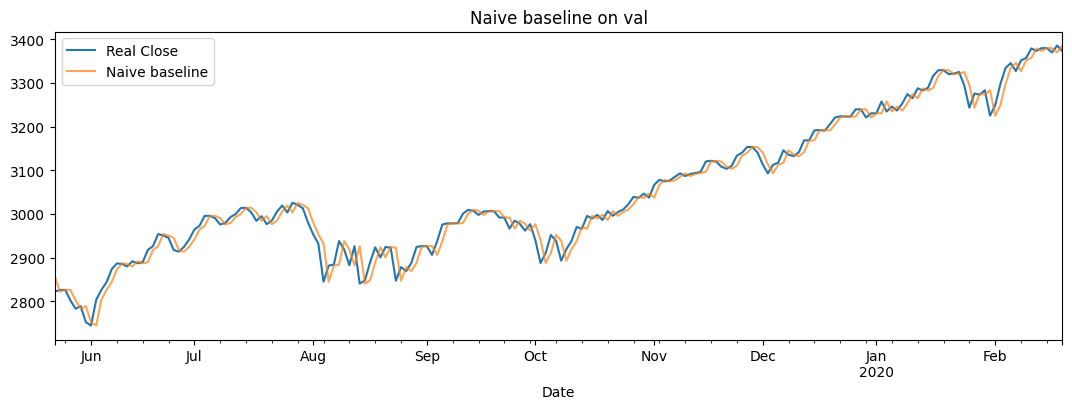

In [156]:
fig, ax = plt.subplots(figsize=(13,4))
y_true.plot(ax=ax, label='Real Close')
y_pred.plot(ax=ax, label='Naive baseline', alpha=0.7)
ax.set_title('Naive baseline on val')
ax.legend()
plt.show()

### Drift

In [157]:
T = len(train)
slope = (train[target].iloc[-1] - train[target].iloc[0]) / (T - 1)
last_train_value = train[target].iloc[-1]

In [158]:
h = np.arange(1, len(val) + 1)
y_pred = pd.Series(last_train_value + h * slope, index=val.index)

In [159]:
y_true = val[target]

In [160]:
mae  = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"Drift baseline | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

Drift baseline | MAE: 127.64 | RMSE: 163.38 | MAPE: 4.0322%


In [161]:
results['drift_val'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

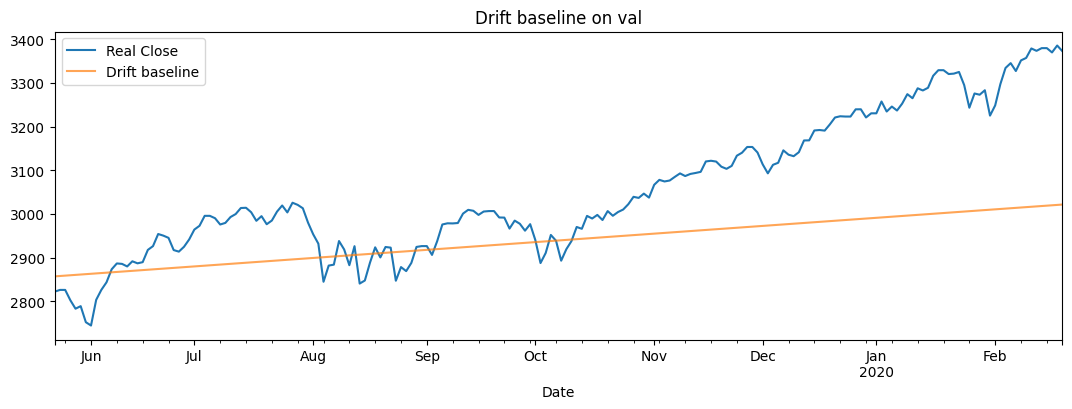

In [162]:
fig, ax = plt.subplots(figsize=(13,4))
y_true.plot(ax=ax, label='Real Close')
y_pred.plot(ax=ax, label='Drift baseline', alpha=0.7)
ax.set_title('Drift baseline on val')
ax.legend()
plt.show()

## ARIMA

In [ ]:
model=ARIMA(train[target],order=(1,1,1))
model_fit=model.fit()
model_fit.summary()

'model=ARIMA(train[target],order=(1,1,1))\nmodel_fit=model.fit()\nmodel_fit.summary()'

In [164]:
residuals = pd.DataFrame(model_fit.resid)
residuals.describe()

,0
count,913.000000
mean,3.113645
std,71.842456
min,-111.405072
25%,-5.924845
50%,0.986530
75%,10.185817
max,2086.590088


Text(0, 0.5, 'density')

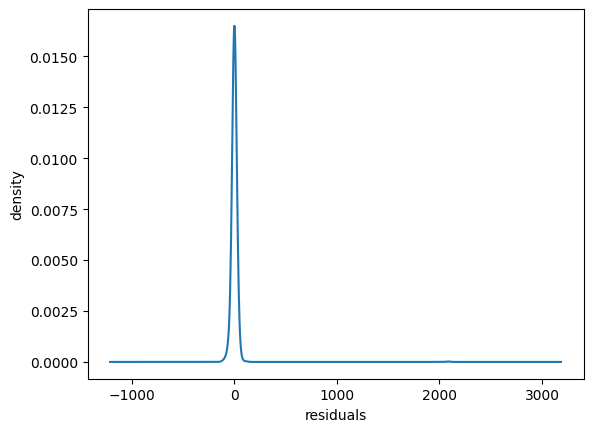

In [165]:
residuals.plot(kind="kde", legend=False)
plt.xlabel("residuals")
plt.ylabel("density")

In [166]:
history = list(train[target].values)
predictions = []
for i in range(len(val)):
    model = ARIMA(history, order=(1, 1, 1))
    model_fit = model.fit() 
    yhat = model_fit.forecast(steps=1)[0]
    predictions.append(yhat) 
    actual=val[target].iloc[i]
    history.append(actual)

y_pred_arima = pd.Series(predictions, index=val.index)
y_true = val[target]

In [171]:
mae  = mean_absolute_error(y_true, y_pred_arima)
rmse = root_mean_squared_error(y_true, y_pred_arima)
mape = mean_absolute_percentage_error(y_true, y_pred_arima)
print(f"ARIMA | MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.4%}")

ARIMA | MAE: 16.45 | RMSE: 22.44 | MAPE: 0.5458%


In [168]:
results['ARIMA_val'] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

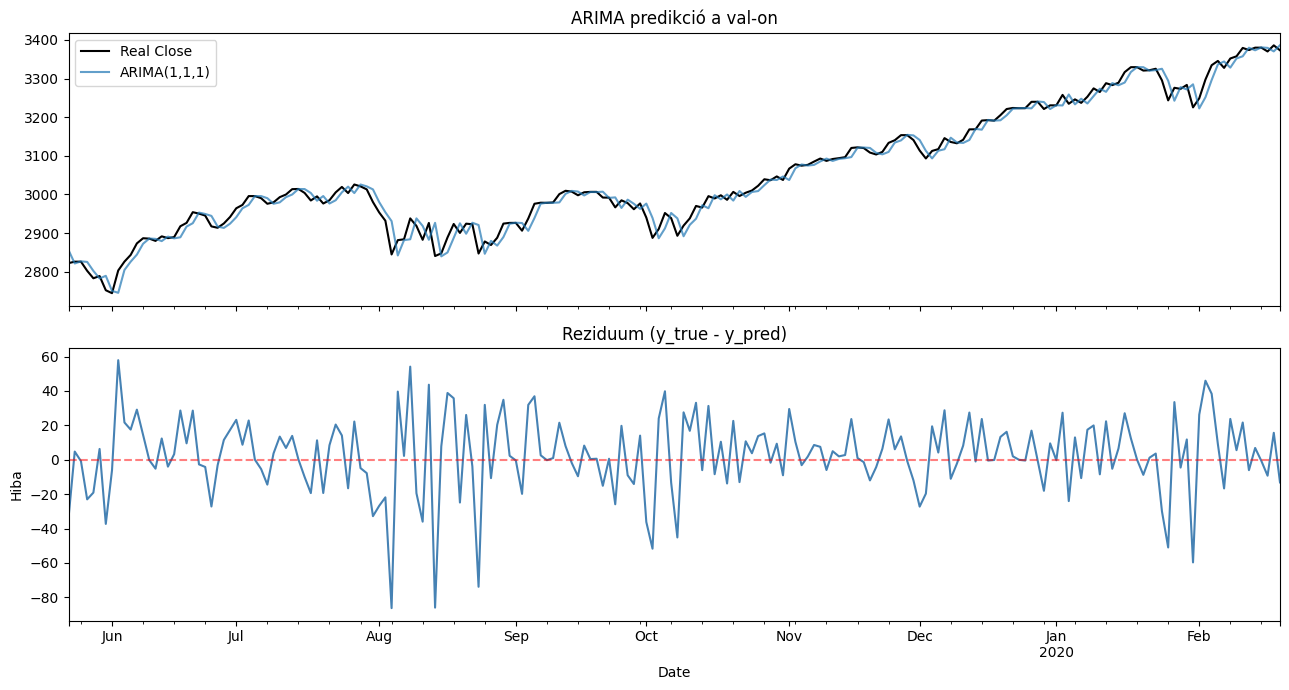

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

y_true.plot(ax=axes[0], label='Real Close', color='black')
y_pred_arima.plot(ax=axes[0], label='ARIMA(1,1,1)', alpha=0.7)
axes[0].set_title('ARIMA predikció a val-on')
axes[0].legend()

residuals = y_true - y_pred_arima
residuals.plot(ax=axes[1], color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Reziduum (y_true - y_pred)')
axes[1].set_ylabel('Hiba')

plt.tight_layout()
plt.show()

##### ARIMA can be 'tuned' using auto_arima, but i move on to XGBoost!

## XGBoost
